In [1]:
!pip install -q \
    "xgboost==2.0.3" \
    "shap==0.45.0" \
    "imbalanced-learn==0.13.0" \
    "scikit-learn==1.4.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap
import joblib

sns.set_style("whitegrid")

plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


3.Upload Data

In [3]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_URL)
print(f"Loaded real Telco dataset from GitHub: {df.shape}")

df.head()


Loaded real Telco dataset from GitHub: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Dataset Shape:
(7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


4. Check Missing Values

In [6]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [8]:
print("Missing TotalCharges:")
print(df["TotalCharges"].isnull().sum())

Missing TotalCharges:
11


In [9]:
df = df.dropna().reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (7032, 21)


5. Remove Customer ID (not useful for prediction)

In [10]:
df = df.drop(
    columns=["customerID"]
)

6. Convert Churn to 0/1

In [11]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [12]:
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

Churn
0    5163
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


7. EDA

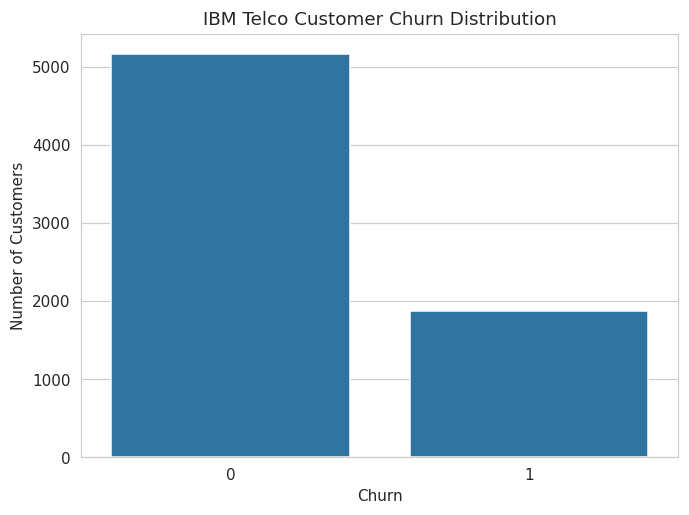

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("IBM Telco Customer Churn Distribution")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Churn by Contract

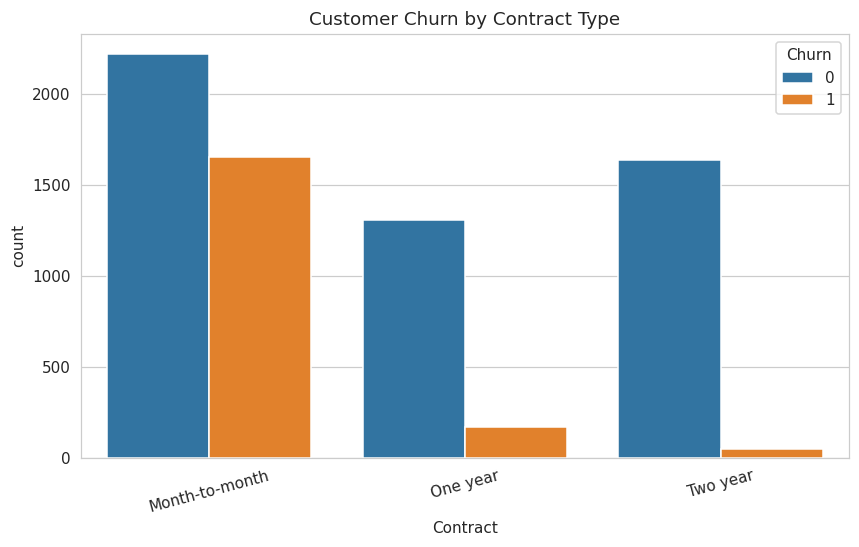

In [14]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")

plt.xticks(rotation=15)

plt.show()

Churn by Internet Service

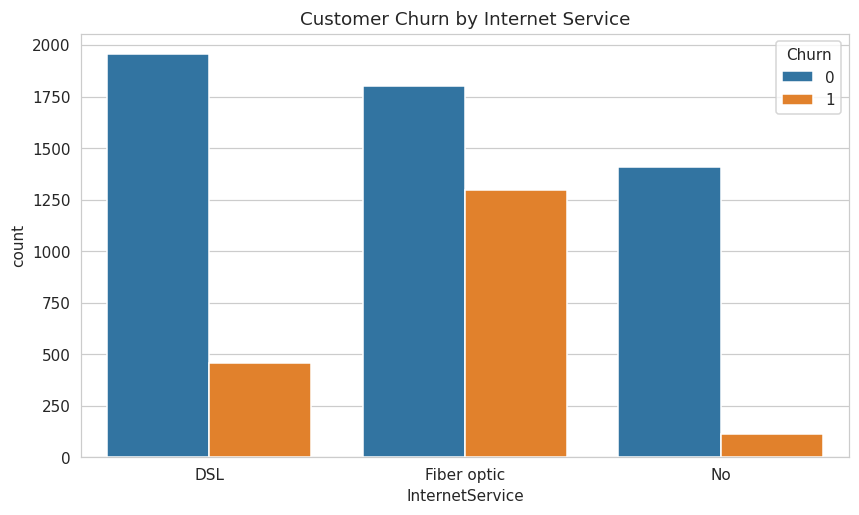

In [15]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")

plt.show()

Churn vs Tenure

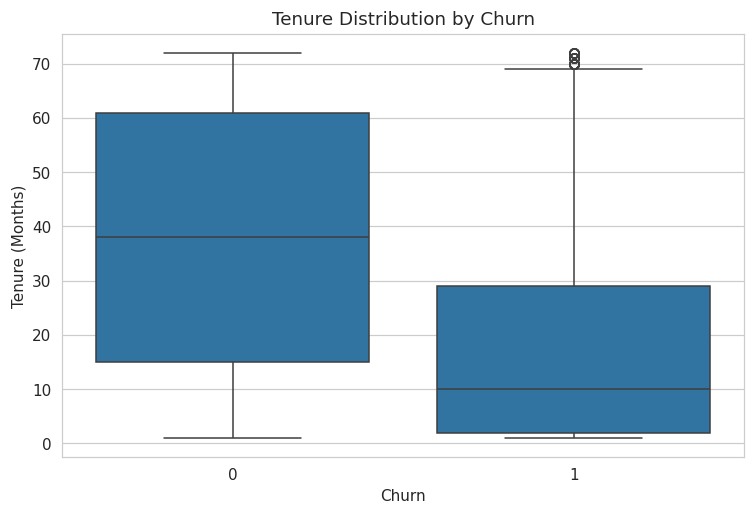

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Churn vs Monthly Charges

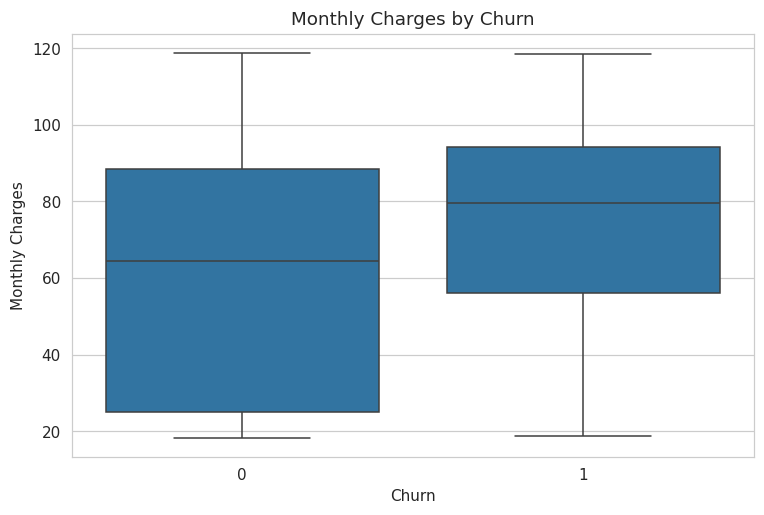

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

8. Define X and y

In [18]:
X = df.drop(
    columns=["Churn"]
)

y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


9. Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5625, 19)
Testing : (1407, 19)


10. Identify Feature Types

In [20]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


11. Preprocessing

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [23]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [24]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Number of processed features:",
    len(feature_names)
)

Number of processed features: 45


12. SMOTE

In [25]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64


In [26]:
smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

In [27]:
print("\nAfter SMOTE:")
print(
    pd.Series(y_train_balanced)
    .value_counts()
)


After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


13. Train Four Individual Models

In [28]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(
    X_train_balanced,
    y_train_balanced
)

LogisticRegression(max_iter=1000, random_state=42)

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [30]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model.fit(
    X_train_balanced,
    y_train_balanced
)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [31]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

14. Model Evaluation Function

In [32]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    results = {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    }

    return results

In [33]:
results = []

results.append(
    evaluate_model(
        logistic_model,
        X_test_processed,
        y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        rf_model,
        X_test_processed,
        y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        gb_model,
        X_test_processed,
        y_test,
        "Gradient Boosting"
    )
)

results.append(
    evaluate_model(
        xgb_model,
        X_test_processed,
        y_test,
        "XGBoost"
    )
)

In [34]:
results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.732054,0.497436,0.778075,0.606882,0.833449
1,Random Forest,0.770434,0.558352,0.652406,0.601726,0.824558
2,Gradient Boosting,0.768301,0.551724,0.684492,0.610979,0.834109
3,XGBoost,0.778252,0.577889,0.614973,0.595855,0.828755


15. Voting Ensemble

In [35]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", logistic_model),
        ("rf", rf_model),
        ("gb", gb_model),
        ("xgb", xgb_model)
    ],
    voting="soft"
)

voting_model.fit(
    X_train_balanced,
    y_train_balanced
)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('rf',
                              RandomForestClassifier(max_depth=12,
                                                     min_samples_split=5,
                                                     n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.05,
                                                         n_estimators=200,
                                                         random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsa...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=-1,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [36]:
voting_result = evaluate_model(
    voting_model,
    X_test_processed,
    y_test,
    "Voting Ensemble"
)

results.append(voting_result)

16. Stacking Ensemble

In [37]:
stacking_model = StackingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=1000
            )
        ),

        (
            "rf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),

        (
            "gb",
            GradientBoostingClassifier(
                n_estimators=150,
                random_state=RANDOM_STATE
            )
        ),

        (
            "xgb",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ],

    final_estimator=LogisticRegression(
        max_iter=1000
    ),

    stack_method="predict_proba",

    cv=5,

    n_jobs=-1
)

In [38]:
stacking_model.fit(
    X_train_balanced,
    y_train_balanced
)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression(max_iter=1000)),
                               ('rf',
                                RandomForestClassifier(n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=150,
                                                           random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None...
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=4,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=-1,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
                   stack_method='predict_proba')

In [39]:
stacking_result = evaluate_model(
    stacking_model,
    X_test_processed,
    y_test,
    "Stacking Ensemble"
)

results.append(stacking_result)

17. Final Model Comparison

In [40]:
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Voting Ensemble,0.771855,0.557235,0.689840,0.616487,0.834402
2,Gradient Boosting,0.768301,0.551724,0.684492,0.610979,0.834109
0,Logistic Regression,0.732054,0.497436,0.778075,0.606882,0.833449
3,XGBoost,0.778252,0.577889,0.614973,0.595855,0.828755
1,Random Forest,0.770434,0.558352,0.652406,0.601726,0.824558
5,Stacking Ensemble,0.778252,0.585165,0.569519,0.577236,0.819190


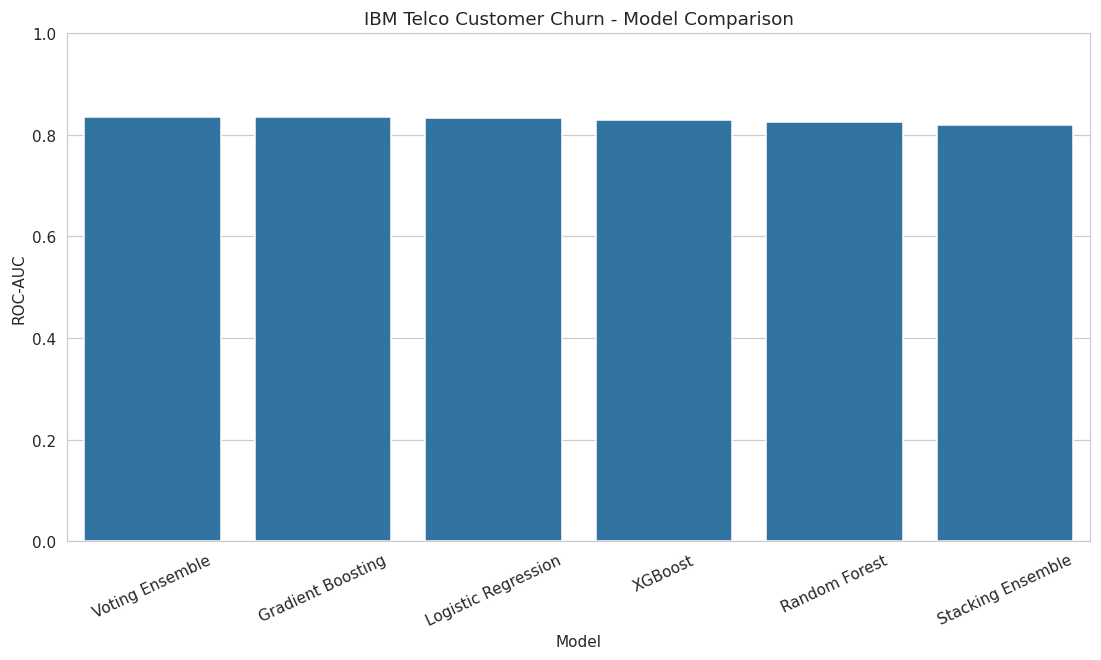

In [41]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="ROC-AUC"
)

plt.title(
    "IBM Telco Customer Churn - Model Comparison"
)

plt.xticks(rotation=25)

plt.ylim(0, 1)

plt.show()

18. Confusion Matrix

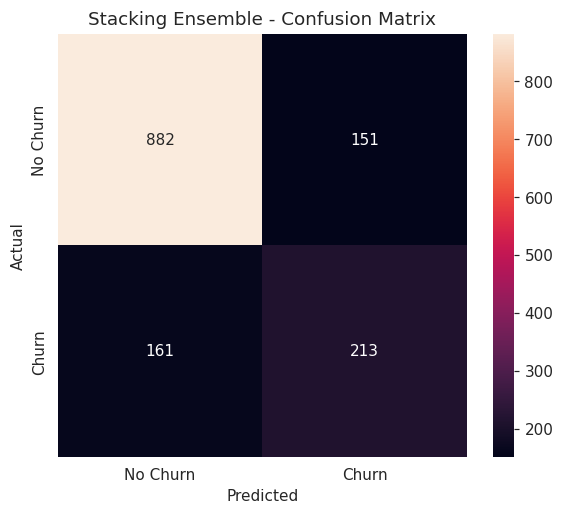

In [42]:
y_pred = stacking_model.predict(
    X_test_processed
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Stacking Ensemble - Confusion Matrix"
)

plt.show()

19. Classification Report

In [43]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1033
       Churn       0.59      0.57      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



20. ROC Curves

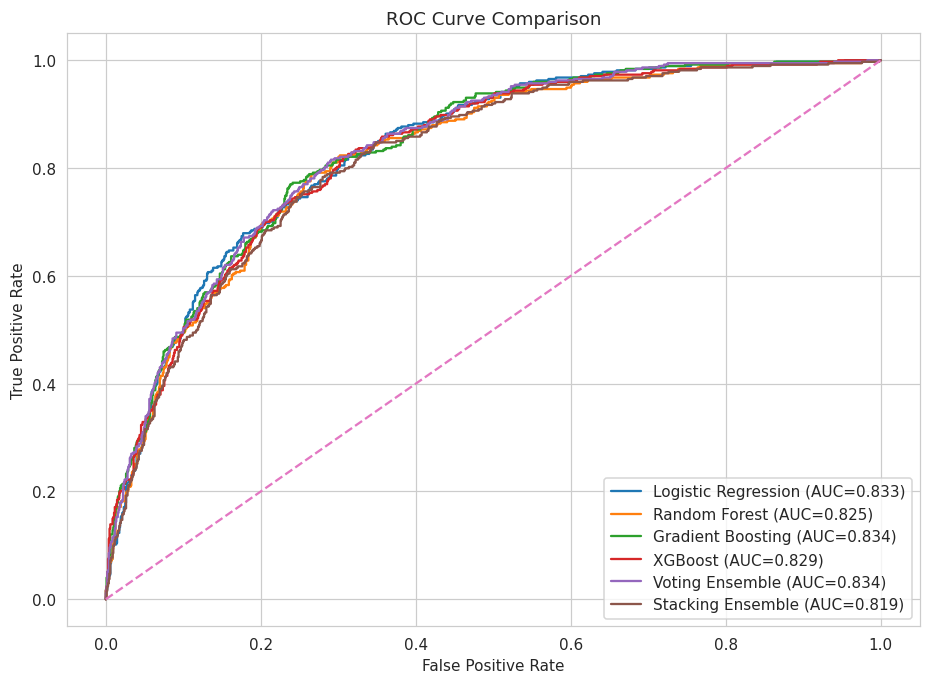

In [44]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "Voting Ensemble": voting_model,
    "Stacking Ensemble": stacking_model
}

plt.figure(figsize=(10, 7))

for name, model in models.items():

    probability = model.predict_proba(
        X_test_processed
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

21. SHAP Interpretability

In [45]:
explainer = shap.TreeExplainer(
    xgb_model
)

In [46]:
X_shap = X_test_processed[
    :500
]

In [47]:
shap_values = explainer.shap_values(
    X_shap
)

22. SHAP Summary Plot

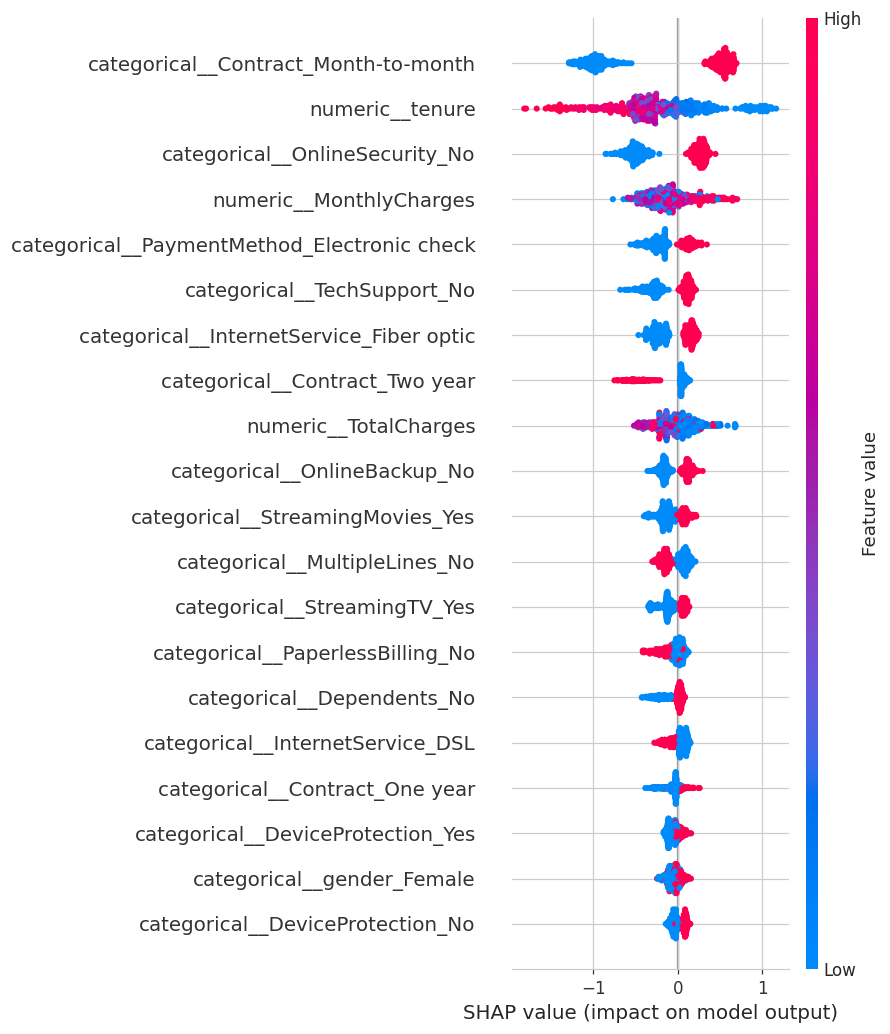

In [48]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

23. Top Churn Drivers

In [49]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,

    "Mean_Absolute_SHAP":
        np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

display(
    shap_importance.head(15)
)

,Feature,Mean_Absolute_SHAP
36,categorical__Contract_Month-to-month,0.738612
1,numeric__tenure,0.485396
18,categorical__OnlineSecurity_No,0.384580
2,numeric__MonthlyCharges,0.227232
43,categorical__PaymentMethod_Electronic check,0.210969
27,categorical__TechSupport_No,0.205919
16,categorical__InternetService_Fiber optic,0.199837
38,categorical__Contract_Two year,0.173204
3,numeric__TotalCharges,0.168760
21,categorical__OnlineBackup_No,0.148139


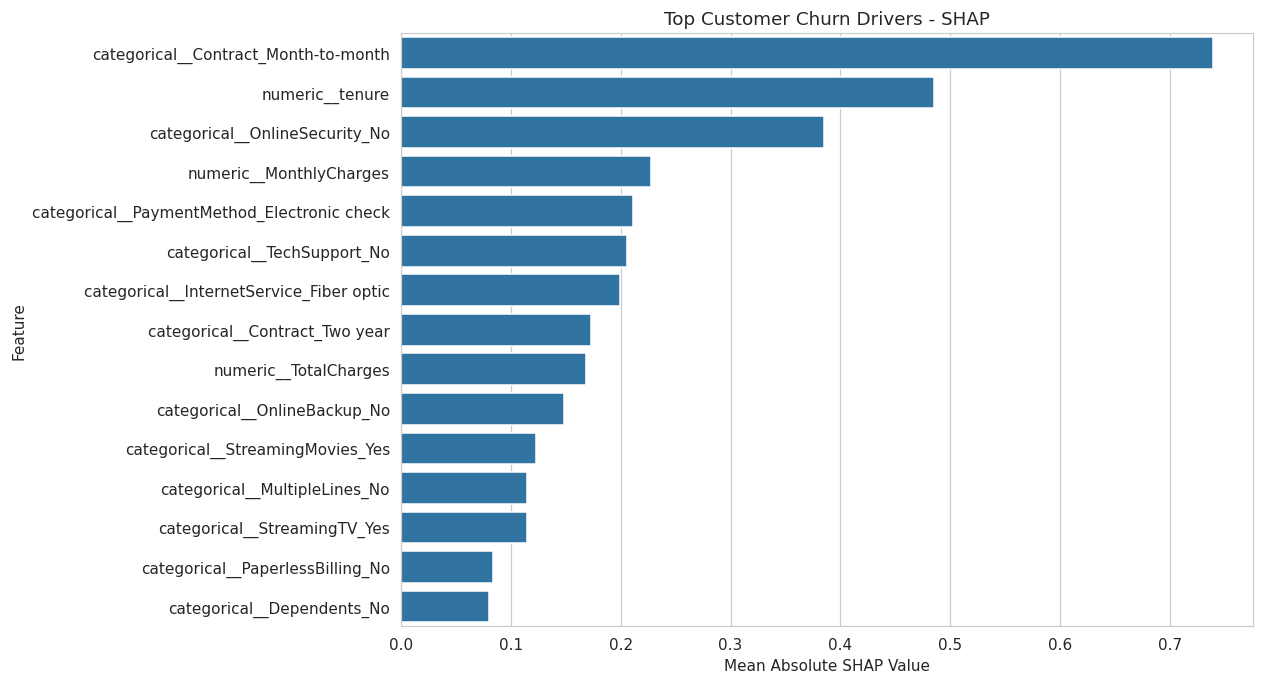

In [50]:
top_features = shap_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Mean_Absolute_SHAP",
    y="Feature"
)

plt.title(
    "Top Customer Churn Drivers - SHAP"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Feature")

plt.show()

24. Individual Customer Explanation

In [51]:
customer_index = 0

customer = X_test_processed[
    customer_index:customer_index + 1
]

prediction = xgb_model.predict(
    customer
)[0]

probability = xgb_model.predict_proba(
    customer
)[0][1]

print(
    "Prediction:",
    "Churn" if prediction == 1 else "No Churn"
)

print(
    f"Churn Probability: {probability:.2%}"
)

Prediction: No Churn
Churn Probability: 0.59%


In [52]:
customer_shap = explainer.shap_values(
    customer
)

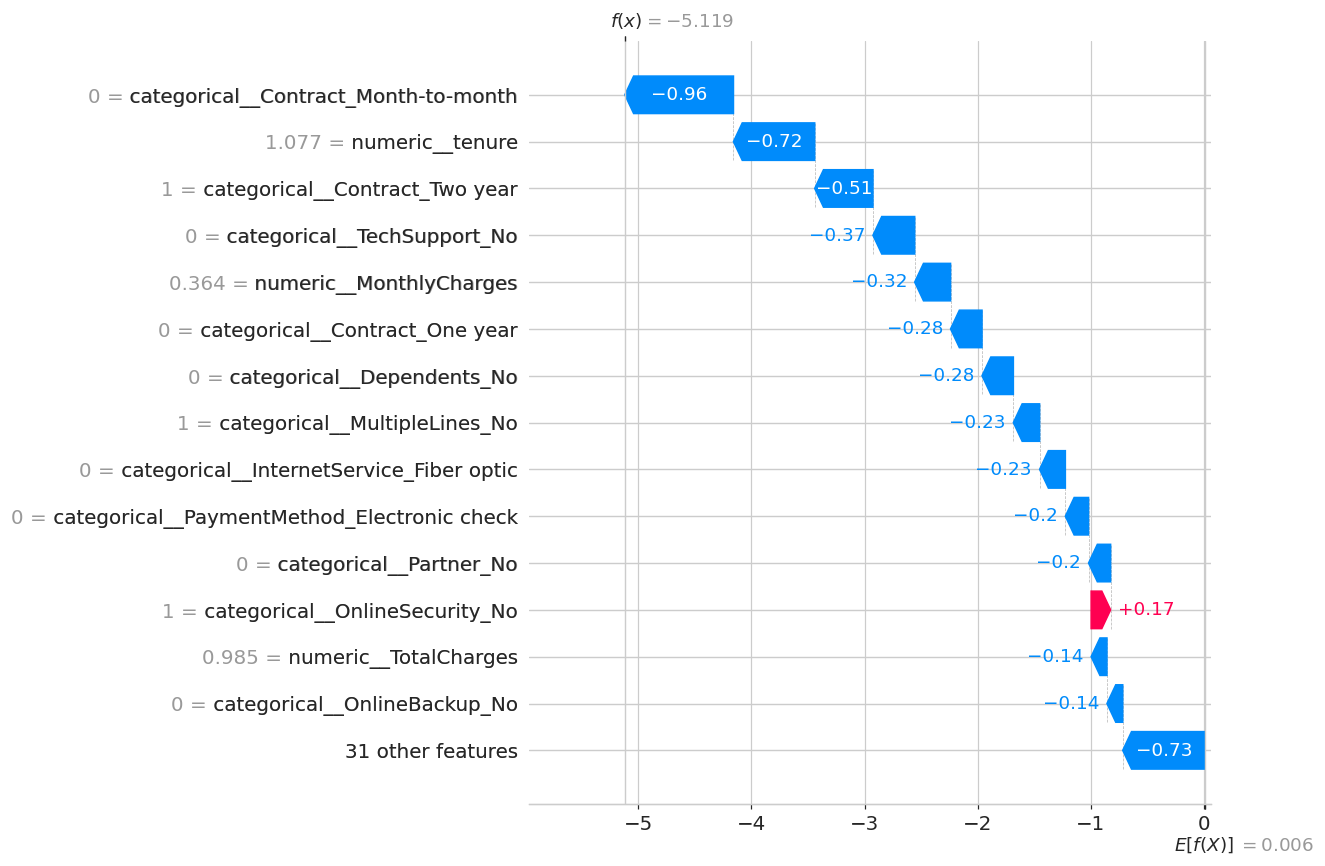

In [53]:
shap_exp = shap.Explanation(
    values=customer_shap[0],
    base_values=explainer.expected_value,
    data=customer[0],
    feature_names=feature_names
)

shap.plots.waterfall(
    shap_exp,
    max_display=15
)